# Chatbot with HITL (Human in the Loop)

Agent 처리도중 사람의 개입이 필요한 경우 iterrupt처리할 수 있다.
- 사람의 개입(tool)
- 사람 메세지(command)로 대화를 재개할 수 있다.

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://apac.api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [2]:
# Tavily 도구 생성
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)

## 사람 개입 도구

In [3]:
from langchain_core.tools import tool  # Tool 데코레이터
from langgraph.types import interrupt  # 사람 응답을 기다리는 interrupt

@tool
def human_assist(query):
    """ 사람의 개입이 필요하면 이 도구를 사용합니다. """
    human_response = interrupt({'query': query})  # 사람의 응답이 올때까지 입력 대기
    return human_response['data']  # 사람의 응답 데이터

In [4]:
from typing import TypedDict, Annotated, List     # 타입 힌트 도구
from langgraph.graph.message import add_messages  # 메시지 누적 처리를 해줄 헬퍼
from langchain.chat_models import init_chat_model

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages: Annotated[List, add_messages]  # messages 필드가 add_messages 규칙으로 누적 저장

llm = init_chat_model('gpt-5.4-mini')
tools = [tavily_tool, human_assist]
llm_with_tools = llm.bind_tools(tools)  # llm에 도구 스펙 파인딩

# State의 messages를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    response = llm_with_tools.invoke(state['messages'])  # 누적된 메시지 리스트로 LLM 호출
    return {'messages': [response]}  # add_messages 규칙에 의해 기존 messages에 응답이 누적됨

In [5]:
# 메모리 기반 체크포인트 저장소 (인메모리)
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()  # 상태 체크포인트를 RAM에 저장하는 객체

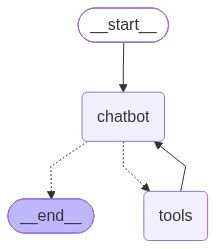

In [6]:
# langgraph.prebuilt 모듈의 ToolNode, tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State)  # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

builder.add_edge(START, 'chatbot')  # 시작 노드 -> chatbot 노드

builder.add_node('chatbot', chatbot)  # chatbot 노드
builder.add_node('tools', tool_node)  # tools 노드

builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools', 'chatbot')

graph = builder.compile(checkpointer = memory)  # 체크포인터를 포함하여 실행 가능한 그래프로 컴파일

graph  # 그래프 객체

## 챗봇 실행

In [7]:
from pprint import pprint

# 스냅샷 출력 함수 : 저장된 상태(messages)와 다음 실행 노드(next) 확인
def print_snapshot(graph, config):
    snapshot = graph.get_state(config)  # 해당 config(thread_id)의 스냅샷 조회

    if 'messages' in snapshot.values:       # messages가 존재하면
        pprint(snapshot.values['messages'])  # 누적된 messages 출력
    else:
        print("메시지가 없음!")
    
    print(f"Next: {snapshot.next}")  # 다음 실행 노드 출력 (튜플)

print(print_snapshot(graph, {'configurable': {'thread_id': 'user1'}}))

메시지가 없음!
Next: ()
None


In [8]:
user1_config = {'configurable': {'thread_id': 'user1'}}

state = {'messages': [('human', 'langgraph를 멀티에이전트 설계에서 사용하는 이유는 뭐야?')]}

response = graph.invoke(state, user1_config)  # 그래프 실행 (START -> CHATBOT -> (tool 루프) or END)
print(response['messages'][-1].content)

LangGraph를 멀티에이전트 설계에서 쓰는 이유는 **에이전트 간 흐름을 “상태 기반 그래프”로 명확하게 제어할 수 있기 때문**이에요.  
단순히 여러 LLM을 연결하는 수준이 아니라, **누가 언제 무엇을 보고 어떤 상태를 갱신하는지**를 구조적으로 설계할 수 있습니다.

핵심 이유를 정리하면:

1. **복잡한 워크플로우를 표현하기 쉬움**
   - 멀티에이전트는 보통
     - 계획
     - 역할 분담
     - 검증
     - 재시도
     - 종료 조건
     같은 분기와 루프가 많습니다.
   - LangGraph는 이런 흐름을 **노드 + 엣지 + 조건 분기**로 표현하기 좋아요.

2. **상태(state)를 중심으로 설계 가능**
   - 에이전트가 각자 따로 노는 게 아니라, 공통 상태를 읽고/쓰는 방식으로 동작시킬 수 있습니다.
   - 예를 들어:
     - 현재 작업 목표
     - 중간 추론 결과
     - 도구 호출 결과
     - 에러/재시도 횟수
   - 이런 것들을 상태로 관리하면 협업 구조가 깔끔해집니다.

3. **루프와 재귀 제어가 편함**
   - 멀티에이전트는 한 번에 끝나는 경우보다
     - 검토 후 수정
     - 실패 시 다른 에이전트 호출
     - 조건 만족할 때까지 반복
     같은 패턴이 많습니다.
   - LangGraph는 이런 반복 흐름을 자연스럽게 다룰 수 있습니다.

4. **역할 분리가 명확함**
   - 예를 들어:
     - Planner agent: 계획 수립
     - Researcher agent: 정보 수집
     - Critic agent: 결과 검토
     - Executor agent: 실제 실행
   - 각 역할을 그래프의 노드로 분리하면 유지보수가 쉬워집니다.

5. **디버깅과 관찰이 쉬움**
   - 에이전트 시스템은 “왜 이런 답이 나왔지?”를 추적하기 어려운데,
   - LangGraph는 그래프 구조로 되어 있어서
     - 

In [9]:
print_snapshot(graph, user1_config)

[HumanMessage(content='langgraph를 멀티에이전트 설계에서 사용하는 이유는 뭐야?', additional_kwargs={}, response_metadata={}, id='6d3efec8-cb48-4e80-8f03-3054786c178f'),
 AIMessage(content='LangGraph를 멀티에이전트 설계에서 쓰는 이유는 **에이전트 간 흐름을 “상태 기반 그래프”로 명확하게 제어할 수 있기 때문**이에요.  \n단순히 여러 LLM을 연결하는 수준이 아니라, **누가 언제 무엇을 보고 어떤 상태를 갱신하는지**를 구조적으로 설계할 수 있습니다.\n\n핵심 이유를 정리하면:\n\n1. **복잡한 워크플로우를 표현하기 쉬움**\n   - 멀티에이전트는 보통\n     - 계획\n     - 역할 분담\n     - 검증\n     - 재시도\n     - 종료 조건\n     같은 분기와 루프가 많습니다.\n   - LangGraph는 이런 흐름을 **노드 + 엣지 + 조건 분기**로 표현하기 좋아요.\n\n2. **상태(state)를 중심으로 설계 가능**\n   - 에이전트가 각자 따로 노는 게 아니라, 공통 상태를 읽고/쓰는 방식으로 동작시킬 수 있습니다.\n   - 예를 들어:\n     - 현재 작업 목표\n     - 중간 추론 결과\n     - 도구 호출 결과\n     - 에러/재시도 횟수\n   - 이런 것들을 상태로 관리하면 협업 구조가 깔끔해집니다.\n\n3. **루프와 재귀 제어가 편함**\n   - 멀티에이전트는 한 번에 끝나는 경우보다\n     - 검토 후 수정\n     - 실패 시 다른 에이전트 호출\n     - 조건 만족할 때까지 반복\n     같은 패턴이 많습니다.\n   - LangGraph는 이런 반복 흐름을 자연스럽게 다룰 수 있습니다.\n\n4. **역할 분리가 명확함**\n   - 예를 들어:\n     - Planner agent: 계획 수립\n     - Researcher age

### 케이크샾 챗봇

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

system_prompt = """
**Instruction**
사용자는 케이크 주문, 메뉴 문의, 매장 정보 등을 챗봇에 요청할 수 있다.
챗봇은 친절하고 정확하게 답변한다.

**Context**
당신은 프리미엄 케이크샵의 공식 챗봇이다.
- 운영 시간: 매일 09:00–21:00
- 주요 메뉴: 생크림 케이크, 초코 케이크, 치즈 케이크, 시즌 한정 케이크
- 매장 위치: 서울 강남구 신사동 123-45
- 연락처: 02-1234-5678

**Example**
> **User:** “다음 주 수요일 오후 3시에 케이크 예약 가능한가요?”
> **Bot:** “안녕하세요! 다음 주 수요일(2025년 7월 16일) 오후 3시에 예약 가능합니다. 예약을 원하시면 성함과 연락처를 알려주세요.”

**Output Indicator**
- 챗봇 응답은 한 문단 이내로 간결하게 제시한다.
- 필요한 경우 날짜·시간은 YYYY년 M월 D일 형식으로 명시한다.
- 추가 질문이 필요할 때에는 “추가로 궁금하신 점이 있으면 말씀해주세요.” 로 마무리한다.
- 그외 답변하기 어려운 경우, human_assist 도구를 사용하여 인간의 도움을 요청한다.
"""  # 시스템 지침/컨텍스트/출력 규칙 정의

user_prompt = '당근케익 4호가 홈페이지에서 구매가 안되는데, 매니져님께 구매가능여부를 묻고 싶어요.'  # 사용자 요청 문장

prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    ('human', '{user_prompt}')
])

state = {'messages': prompt.format_messages(user_prompt=user_prompt)}
response = graph.invoke(state, user1_config)
print(response['messages'][-1].content)

In [11]:
print_snapshot(graph, user1_config)

[HumanMessage(content='langgraph를 멀티에이전트 설계에서 사용하는 이유는 뭐야?', additional_kwargs={}, response_metadata={}, id='6d3efec8-cb48-4e80-8f03-3054786c178f'),
 AIMessage(content='LangGraph를 멀티에이전트 설계에서 쓰는 이유는 **에이전트 간 흐름을 “상태 기반 그래프”로 명확하게 제어할 수 있기 때문**이에요.  \n단순히 여러 LLM을 연결하는 수준이 아니라, **누가 언제 무엇을 보고 어떤 상태를 갱신하는지**를 구조적으로 설계할 수 있습니다.\n\n핵심 이유를 정리하면:\n\n1. **복잡한 워크플로우를 표현하기 쉬움**\n   - 멀티에이전트는 보통\n     - 계획\n     - 역할 분담\n     - 검증\n     - 재시도\n     - 종료 조건\n     같은 분기와 루프가 많습니다.\n   - LangGraph는 이런 흐름을 **노드 + 엣지 + 조건 분기**로 표현하기 좋아요.\n\n2. **상태(state)를 중심으로 설계 가능**\n   - 에이전트가 각자 따로 노는 게 아니라, 공통 상태를 읽고/쓰는 방식으로 동작시킬 수 있습니다.\n   - 예를 들어:\n     - 현재 작업 목표\n     - 중간 추론 결과\n     - 도구 호출 결과\n     - 에러/재시도 횟수\n   - 이런 것들을 상태로 관리하면 협업 구조가 깔끔해집니다.\n\n3. **루프와 재귀 제어가 편함**\n   - 멀티에이전트는 한 번에 끝나는 경우보다\n     - 검토 후 수정\n     - 실패 시 다른 에이전트 호출\n     - 조건 만족할 때까지 반복\n     같은 패턴이 많습니다.\n   - LangGraph는 이런 반복 흐름을 자연스럽게 다룰 수 있습니다.\n\n4. **역할 분리가 명확함**\n   - 예를 들어:\n     - Planner agent: 계획 수립\n     - Researcher age

In [ ]:
# 사람 개입
from langgraph.types import Command  # interrupt를 재개(resume)하기 위한 Command

human_response = "물론입니다. 구매 가능하시고요. 홈페이지 구매 가능하도록 채널 열어놓겠습니다. 가격은 15만원입니다. 감사합니다."

command = Command(resume={'data': human_response})  # interrupt에 전달할 재개 메시지
response = graph.invoke(command, user1_config)  # 중단된 그래프를 thread_id user1에서 재개 실행
print(response['messages'][-1].content)

안녕하세요! 당근케익 4호는 구매 가능하며, 홈페이지에서도 구매하실 수 있도록 처리해두겠습니다. 가격은 15만원입니다. 추가로 궁금하신 점이 있으면 말씀해주세요.


In [13]:
print_snapshot(graph, user1_config)

[HumanMessage(content='langgraph를 멀티에이전트 설계에서 사용하는 이유는 뭐야?', additional_kwargs={}, response_metadata={}, id='6d3efec8-cb48-4e80-8f03-3054786c178f'),
 AIMessage(content='LangGraph를 멀티에이전트 설계에서 쓰는 이유는 **에이전트 간 흐름을 “상태 기반 그래프”로 명확하게 제어할 수 있기 때문**이에요.  \n단순히 여러 LLM을 연결하는 수준이 아니라, **누가 언제 무엇을 보고 어떤 상태를 갱신하는지**를 구조적으로 설계할 수 있습니다.\n\n핵심 이유를 정리하면:\n\n1. **복잡한 워크플로우를 표현하기 쉬움**\n   - 멀티에이전트는 보통\n     - 계획\n     - 역할 분담\n     - 검증\n     - 재시도\n     - 종료 조건\n     같은 분기와 루프가 많습니다.\n   - LangGraph는 이런 흐름을 **노드 + 엣지 + 조건 분기**로 표현하기 좋아요.\n\n2. **상태(state)를 중심으로 설계 가능**\n   - 에이전트가 각자 따로 노는 게 아니라, 공통 상태를 읽고/쓰는 방식으로 동작시킬 수 있습니다.\n   - 예를 들어:\n     - 현재 작업 목표\n     - 중간 추론 결과\n     - 도구 호출 결과\n     - 에러/재시도 횟수\n   - 이런 것들을 상태로 관리하면 협업 구조가 깔끔해집니다.\n\n3. **루프와 재귀 제어가 편함**\n   - 멀티에이전트는 한 번에 끝나는 경우보다\n     - 검토 후 수정\n     - 실패 시 다른 에이전트 호출\n     - 조건 만족할 때까지 반복\n     같은 패턴이 많습니다.\n   - LangGraph는 이런 반복 흐름을 자연스럽게 다룰 수 있습니다.\n\n4. **역할 분리가 명확함**\n   - 예를 들어:\n     - Planner agent: 계획 수립\n     - Researcher age